<a href="https://colab.research.google.com/github/preethisedigar/data_analytics_projects/blob/main/employee__salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Employee salary Prediction: - Implement appropriate Machine learning Model on
the Multivariate Data, And Provide us the step-by-step implementation of model,
graphs and reports with Description.(salary_details.csv)

In [ ]:
#import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [ ]:
#read the csv file
data=pd.read_csv('salary_details.csv')
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
data.shape #(no of rows,no of colm)

(48842, 15)

In [ ]:
data.info() #displays information of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
data.describe()  #represents mean median of numerical columns

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
data.isnull().sum() #checks for missing values

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
data.nunique()  #displays unique values present in each col

,0
age,74
workclass,9
fnlwgt,28523
education,16
educational-num,16
marital-status,7
occupation,15
relationship,6
race,5
gender,2


In [ ]:
data.value_counts() #displays count of unique values

age  workclass         fnlwgt  education     educational-num  marital-status      occupation         relationship   race   gender  capital-gain  capital-loss  hours-per-week  native-country  income
21   Private           243368  Preschool     1                Never-married       Farming-fishing    Not-in-family  White  Male    0             0             50              Mexico          <=50K     3
25   Private           308144  Bachelors     13               Never-married       Craft-repair       Not-in-family  White  Male    0             0             40              Mexico          <=50K     3
                       195994  1st-4th       2                Never-married       Priv-house-serv    Not-in-family  White  Female  0             0             40              Guatemala       <=50K     3
30   Private           180317  Assoc-voc     11               Divorced            Machine-op-inspct  Not-in-family  White  Male    0             0             40              United-States   <=50K     2
                       111567  HS-grad       9                Never-married       Craft-repair       Own-child      White  Male    0             0             48              United-States   <=50K     2
                                                                                                                                                                                                        ..
31   Private           155914  Some-college  10               Married-civ-spouse  Farming-fishing    Husband        White  Male    0             0             40              United-States   <=50K     1
                       156192  Some-college  10               Married-civ-spouse  Craft-repair       Husband        White  Male    0             0             40              United-States   >50K      1
                       156464  10th          6                Divorced            Other-service      Not-in-family  White  Male    0             0             40              United-States   <=50K     1
                               Bachelors     13               Never-married       Prof-specialty     Own-child      White  Male    0             0             25              United-States   <=50K     1
90   Self-emp-not-inc  282095  Some-college  10               Married-civ-spouse  Farming-fishing    Husband        White  Male    0             0             40              United-States   <=50K     1
Name: count, Length: 48790, dtype: int64

In [ ]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [ ]:
data.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object


Data is clean and noise free and ready for analysis process!

 categorical features like workclass, education, marital-status, occupation, relationship, race, gender, native-country, and income. We need to encode them into numerical values using LabelEncoder or OneHotEncoder (based on the number of categories).

In [ ]:
# Encode categorical columns
label_encoder = LabelEncoder()
categorical_columns = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

In [ ]:
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,4,226802,1,7,4,7,3,2,1,0,0,40,39,<=50K
1,38,4,89814,11,9,2,5,0,4,1,0,0,50,39,<=50K
2,28,2,336951,7,12,2,11,0,4,1,0,0,40,39,>50K
3,44,4,160323,15,10,2,7,0,2,1,7688,0,40,39,>50K
4,18,0,103497,15,10,4,0,3,4,0,0,0,30,39,<=50K


Feature and Target Separation:

X will be your features (all columns except income).

y will be the target variable (income).

In [ ]:
# Split the data into features (X) and target (y)
X = data.drop('income', axis=1)
y = data['income']

In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


why random forest classifier among other machine learning algorithm?

MinMax Scaler / Standard Scaler: Not necessary for Random Forest as it is not sensitive to feature scaling.

Recursive Feature Elimination (RFE): Might not improve performance since Random Forest already selects important features through random splits.

Outliers Detection: Not essential because Random Forest is robust to outliers; outliers typically don't affect performance.


In [ ]:
# Initialize the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
# Train the model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8639574163169209
Classification Report:
               precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7479
        >50K       0.74      0.64      0.69      2290

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769

Confusion Matrix:
 [[6968  511]
 [ 818 1472]]


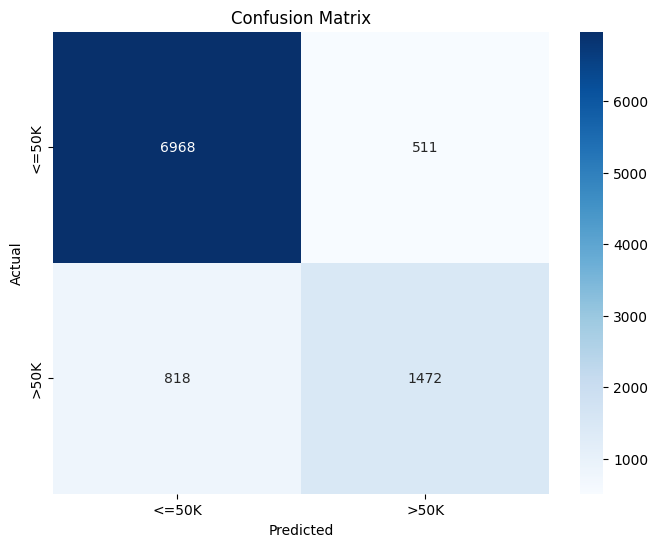

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


ROC Curve and AUC

The ROC curve illustrates the diagnostic ability of the classifier, and the AUC score quantifies its performance.

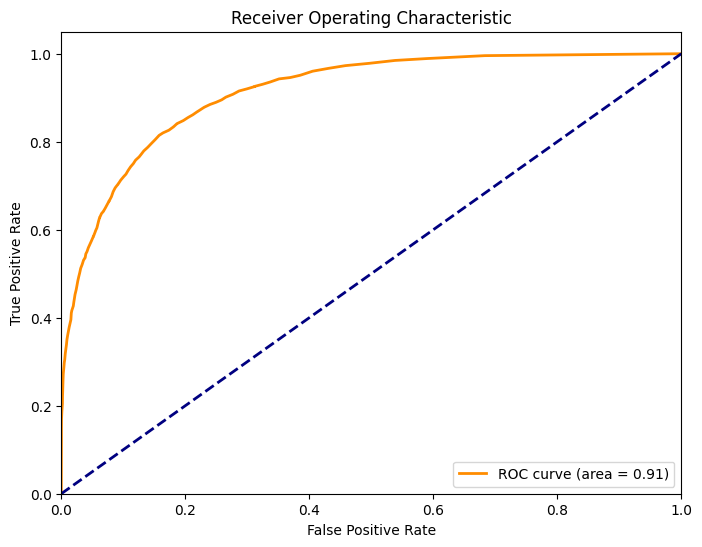

In [ ]:


# Initialize the Random Forest model
best_model = RandomForestClassifier(random_state=42)

# Train the model
best_model.fit(X_train, y_train)

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the target labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Get the predicted probabilities for the positive class
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()



AUC Value of 0.91: An AUC score of 0.91 suggests that there is a 91% chance that the model will correctly rank a randomly chosen positive instance higher than a randomly chosen negative one.

# Analysis of Results:

Overall Accuracy: 86.4% is quite good, but since the dataset has imbalanced classes (more <=50K than >50K), the accuracy is a bit skewed.

Precision and Recall for <=50K: These metrics are strong, indicating that the model is better at predicting the lower-income class.

Precision and Recall for >50K: The model struggles with predicting the higher-income class, which results in lower recall and precision for this category.

 The model is likely to misclassify some >50K as <=50K.

 Accuracy: The model correctly predicted the target variable 86.4% of the time.

Precision and Recall:

Precision for <=50K: 89% of the instances predicted as <=50K were correct.

Recall for <=50K: 93% of the actual <=50K instances were correctly identified.

Precision for >50K: 74% of the instances predicted as >50K were correct.

Recall for >50K: 64% of the actual >50K instances were correctly identified.

F1-Score: The harmonic mean of precision and recall, providing a balance between the two metrics.

Confusion Matrix:

True Negatives (TN): 6,968 instances correctly predicted as <=50K.

False Positives (FP): 511 instances incorrectly predicted as >50K.

False Negatives (FN): 818 instances incorrectly predicted as <=50K.

True Positives (TP): 1,472 instances correctly predicted as >50K.

# Suggestions for Improvement:

Hyperparameter Tuning: Consider optimizing the Random Forest parameters (e.g., n_estimators, max_depth, min_samples_split) to improve performance, especially for the >50K class.

Try Different Models: experiment with models like XGBoost,Linear regression or Logistic Regression

Hyperparameter tuning :involves selecting the optimal set of hyperparameters for a machine learning model to enhance its performance. Hyperparameters are parameters set before training begins and control the training process itself. Proper tuning is crucial, as it can significantly influence the model's performance.

In [ ]:
# Hyperparameter Tuning (Reduced search space for faster execution)
param_grid = {
    'n_estimators': [50, 100],  # Reduced options
    'max_depth': [None, 10],   # Reduced options
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,  # Reduced cross-validation folds
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

y_pred_best = best_model.predict(X_test)
print("Accuracy (best model):", accuracy_score(y_test, y_pred_best))

Best hyperparameters: {'max_depth': 10, 'n_estimators': 100}
Best score: 0.8570112993817408
Accuracy (best model): 0.8635479578257754


In [ ]:
# Ensure y_test and y_pred_test are NumPy arrays
dframe = pd.DataFrame({
    'Actual': y_test.values,  # Convert Series to array
    'Predicted': y_pred # Already an array
})

dframe

,Actual,Predicted
0,<=50K,<=50K
1,<=50K,<=50K
2,>50K,>50K
3,<=50K,<=50K
4,<=50K,>50K
...,...,...
9764,>50K,>50K
9765,>50K,>50K
9766,>50K,<=50K
9767,<=50K,<=50K


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7479
        >50K       0.74      0.64      0.69      2290

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [ ]:
#multivarient analysis

# Encode categorical variables
label_encoder = LabelEncoder()
data['education'] = label_encoder.fit_transform(data['education'])
data['gender'] = label_encoder.fit_transform(data['gender'])

# Select features and target variable
X = data[['age', 'education', 'gender', 'hours-per-week']]  # Features
y = data['income']  # Target variable (income)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




Random Forest Classification Report:
              precision    recall  f1-score   support

       <=50K       0.84      0.90      0.87      7479
        >50K       0.57      0.44      0.50      2290

    accuracy                           0.79      9769
   macro avg       0.71      0.67      0.68      9769
weighted avg       0.78      0.79      0.78      9769



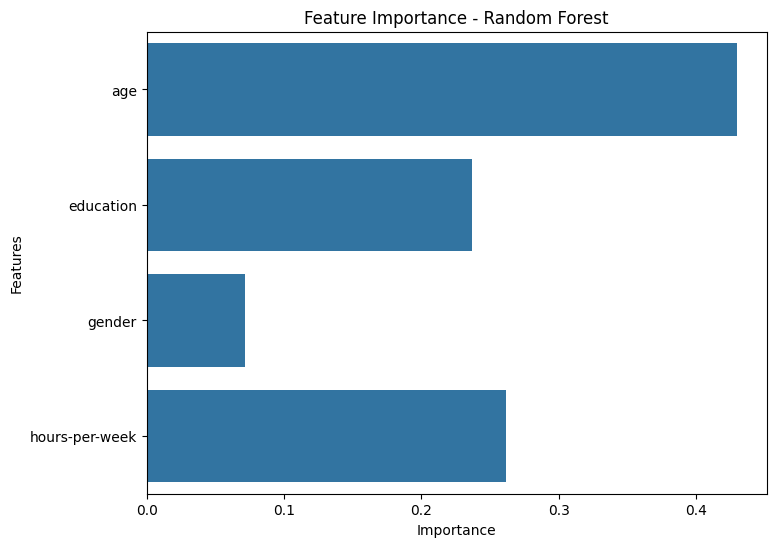

Random Forest Accuracy: 0.7920974511208926


In [ ]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest Model
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature Importance
feature_importances_rf = rf_model.feature_importances_

# Plot Feature Importance
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importances_rf, y=X.columns)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

# Accuracy of Random Forest
print(f"Random Forest Accuracy: {rf_model.score(X_test, y_test)}")
